In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm
from helpers_nw import compute_N
from helpers_nw import *

In [2]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          # = 0.316 wall velocity
tau = 2 * Kn / np.sqrt(np.pi / 2)     # ≈ 0.225 relaxation time

# Domain
L = 1.0
Nc = 50
dx = L / Nc                            # = 0.02

# Particles
Np = 250000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 4.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 4 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = True

In [3]:
def compute_weights_NW(X, x_grid, h):
    diff = (X[None, :] - x_grid[:, None]) / h  # Nc x Np
    W = np.exp(-0.5 * diff**2)
    W /= W.sum(axis=1, keepdims=True)
    return W  # Nc x Np

def compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):
    Nc = W.shape[0]
    if Mbar is not None:
        W_col_sum = W.sum(axis=0)  # Np
        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]  # Np x 3
        M_corrected = M - Mbar + Ubar_at_X
    else:
        M_corrected = M
    
    U = W @ M_corrected             # Nc x 3
    
    T = np.zeros(Nc)
    for c in range(Nc):
        residuals = M_corrected - U[c]
        T[c] = (m / (3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()
        if Mbar is not None and Tbar is not None:
            T[c] += Tbar
    
    return U, T

In [4]:
def evolve_velocity_M(M, mask, U_particle, T_particle, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_particle) * np.exp(-dt/tau) \
            + U_particle \
            + np.sqrt((k * T_particle / m) * (1 - np.exp(-2*dt/tau)))[:, None] * noise

# Add NiNi
def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise, NiNi):
    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
               + dt * N[mask] \
               + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * NiNi[mask], 0.0)) * noise
    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))


In [5]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        # Reflect particle back to boundary
        X[left_mask] = -L/2
        # Re-sample velocity
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        M[left_mask, 0] = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        M[left_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)

        Mbar[left_mask, 0] = np.sqrt(-2*k*Tbar/m * np.log(r1_left))
        Mbar[left_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        # same for right wall

    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        M[right_mask, 0] = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        M[right_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)

        Mbar[right_mask, 0] = -np.sqrt(-2*k*Tbar/m * np.log(r1_right))
        Mbar[right_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        # same for right wall


    return left_mask, right_mask

In [6]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

Ubar = np.zeros((Nc, 3))

W = compute_weights_NW(X, x_grid, h)

if correlated_process:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
else:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)


for step in tqdm(range(1, Nsteps)):

    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 
    
    # Compute weights once per step
    W = compute_weights_NW(X, x_grid, h)
    
    # Sort particles 
    if correlated_process:    
        N, NiNi = compute_N(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)

    # For debugging
        if step in [1, 10, 50, 100, 200, 500, 750]:
            alpha = compute_alpha(M, Mbar, W, dx)
            cbar = compute_cbar(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)
            
            print(f"\n{'='*50}")
            print(f"Step {step}")
            print(f"{'='*50}")
            
            print(f"\n  N statistics:")
            for d, name in enumerate(['x','y','z']):
                print(f"    N[{name}]: mean={np.mean(N[:,d]):+.4f}  std={np.std(N[:,d]):.4f}  max={np.abs(N[:,d]).max():.4f}")
            
            print(f"\n  Particle statistics:")
            print(f"    std(Mbar[:,0]) = {np.std(Mbar[:,0]):.4f}")
            print(f"    std(M-Mbar)    = {np.std(M[:,0]-Mbar[:,0]):.4f}")
            print(f"    mean(M-Mbar)   = {np.mean(M[:,0]-Mbar[:,0]):.4f}")
            
            print(f"\n  Coefficient statistics:")
            print(f"    alpha: mean={np.mean(alpha):+.4f}  std={np.std(alpha):.4f}  max={np.abs(alpha).max():.4f}")
            print(f"    cbar:  mean={np.mean(cbar):+.4f}  std={np.std(cbar):.4f}  max={np.abs(cbar).max():.4f}")
            print(f"    cbar diagonal only:")
            for d in range(3):
                print(f"      cbar[{d},{d}]: mean={np.mean(cbar[:,d,d]):+.4f}  std={np.std(cbar[:,d,d]):.4f}")
            
            # Energy correction health check
            NiNi = compute_NiNi_analytical(alpha, cbar, 
                   compute_gammabar(alpha, M, Mbar, W, dx, m, k, Tbar),
                   -((m/(2*k*Tbar))**2)/tau, tau, Tbar)
            Atilde = (k*Tbar/m)*(1-np.exp(-2*dt/tau)) - dt**2 * NiNi
            print(f"\n  Energy correction A_tilde:")
            print(f"    min={Atilde.min():.6f}  mean={Atilde.mean():.6f}")
            pct_negative = 100 * np.mean(Atilde < 0)
            print(f"    % negative (clamped to 0): {pct_negative:.1f}%")
            print(f"{'='*50}\n")
    
            print(f"U[step,:,0] (wall-normal, should be ~0):")
            print(U[step-1,:,0])
            print(f"U[step,:,1] (streamwise, should be linear):")  
            print(U[step-1,:,1])

    
    W_col_sum = W.sum(axis=0)  # Nc x Np summed over Nc -> shape (Np,)
    T_at_particle = (W.T @ T[step-1]) / W_col_sum   # Np
    U_at_particle = (W.T @ U[step-1]) / W_col_sum[:, None]  # Np x 3

    mask_update = ~mask_wall # exclude wall-hitting particles, because they are already handled  
    
    # Evolve V^i
    noise = np.random.normal(0,1,size=M[mask_update].shape) # Common noise
    evolve_velocity_M(M, mask_update, U_at_particle[mask_update], T_at_particle[mask_update], dt, tau, m, k, noise)

    
    
    if correlated_process:
        # Interpolate to particles
        W_col_sum = W.sum(axis=0)
        NiNi_at_particle = (W.T @ NiNi) / W_col_sum[:, None]  # Np x 3
        #evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise) 
        evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise, NiNi_at_particle)
        
        #Ubar = W @ Mbar 
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar)

  0%|                                                   | 0/399 [00:00<?, ?it/s]


Step 1

  N statistics:
    N[x]: mean=-0.0633  std=16.4268  max=68.7001
    N[y]: mean=+0.0186  std=16.4484  max=89.8168
    N[z]: mean=-0.0014  std=16.4317  max=85.3902

  Particle statistics:
    std(Mbar[:,0]) = 1.0000
    std(M-Mbar)    = 0.0000
    mean(M-Mbar)   = 0.0000

  Coefficient statistics:
    alpha: mean=+0.0000  std=0.0000  max=0.0000
    cbar:  mean=+5.7444  std=8.1237  max=17.2331
    cbar diagonal only:
      cbar[0,0]: mean=+17.2331  std=0.0000
      cbar[1,1]: mean=+17.2331  std=0.0000
      cbar[2,2]: mean=+17.2331  std=0.0000

  Energy correction A_tilde:
    min=0.090797  mean=0.090797
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
U[step,:,1] (streamwise, should be linear):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

  2%|▉                                          | 9/399 [00:04<03:36,  1.80it/s]


Step 10

  N statistics:
    N[x]: mean=-0.0452  std=13.1411  max=77.6551
    N[y]: mean=-0.0243  std=13.5411  max=62.6544
    N[z]: mean=+0.0688  std=13.5472  max=57.1772

  Particle statistics:
    std(Mbar[:,0]) = 1.7301
    std(M-Mbar)    = 1.0317
    mean(M-Mbar)   = 0.0032

  Coefficient statistics:
    alpha: mean=+0.0029  std=0.4939  max=1.3959
    cbar:  mean=+5.3278  std=7.5375  max=16.8216
    cbar diagonal only:
      cbar[0,0]: mean=+15.4820  std=0.2563
      cbar[1,1]: mean=+16.2260  std=0.1885
      cbar[2,2]: mean=+16.2381  std=0.2010

  Energy correction A_tilde:
    min=0.092069  mean=0.094479
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[ 0.25319547  0.24578547  0.23739382  0.22803227  0.21777321  0.20675787
  0.19519004  0.18331068  0.17135695  0.1595176   0.14790183  0.13653464
  0.12537983  0.11437988  0.10349524  0.09272785  0.08212217  0.07174722
  0.06167063  0.05193648  0.04255393  0.03349633  0.02470553  0.01609691
  0.007564

 12%|█████▏                                    | 49/399 [00:25<02:54,  2.01it/s]

...

 25%|██████████▍                               | 99/399 [00:50<02:31,  1.98it/s]


Step 100

  N statistics:
    N[x]: mean=+0.0573  std=13.7419  max=188.9017
    N[y]: mean=-0.2242  std=13.7746  max=129.4500
    N[z]: mean=-0.2090  std=13.6887  max=59.4578

  Particle statistics:
    std(Mbar[:,0]) = 1.8600
    std(M-Mbar)    = 1.6180
    mean(M-Mbar)   = -0.0034

  Coefficient statistics:
    alpha: mean=-0.0213  std=0.7291  max=2.5105
    cbar:  mean=+5.8378  std=8.3086  max=19.3810
    cbar diagonal only:
      cbar[0,0]: mean=+17.0026  std=0.4401
      cbar[1,1]: mean=+17.8448  std=1.1507
      cbar[2,2]: mean=+17.8217  std=1.0948

  Energy correction A_tilde:
    min=0.083606  mean=0.089499
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-0.16372458 -0.15288556 -0.1403388  -0.12623354 -0.11088183 -0.09476422
 -0.07849504 -0.06274124 -0.04810953 -0.03503735 -0.02372848 -0.01415518
 -0.00611855  0.00066226  0.0064616   0.01147719  0.01578502  0.01932235
  0.02190287  0.02326553  0.02315088  0.02138791  0.01796666  0.01307344
  0.00

 50%|████████████████████▍                    | 199/399 [01:43<02:14,  1.48it/s]


Step 200

  N statistics:
    N[x]: mean=-0.0240  std=13.4212  max=133.6969
    N[y]: mean=+0.2625  std=13.5868  max=69.3497
    N[z]: mean=-0.3082  std=13.6827  max=55.8373

  Particle statistics:
    std(Mbar[:,0]) = 1.8530
    std(M-Mbar)    = 1.6148
    mean(M-Mbar)   = 0.0015

  Coefficient statistics:
    alpha: mean=-0.0028  std=0.6934  max=2.4539
    cbar:  mean=+5.8422  std=8.2491  max=19.3370
    cbar diagonal only:
      cbar[0,0]: mean=+16.8993  std=0.6886
      cbar[1,1]: mean=+17.7587  std=0.8243
      cbar[2,2]: mean=+17.7910  std=0.8892

  Energy correction A_tilde:
    min=0.083734  mean=0.089767
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-0.15214859 -0.14152107 -0.12893382 -0.1145179  -0.09861749 -0.08181539
 -0.06490542 -0.04879505 -0.03434921 -0.02222041 -0.0127282  -0.00583335
 -0.00120836  0.00163524  0.00321632  0.00398908  0.00429676  0.00436681
  0.00433096  0.00425574  0.0041741   0.00411365  0.0041182   0.00425907
  0.0046

100%|█████████████████████████████████████████| 399/399 [03:42<00:00,  1.80it/s]


In [7]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

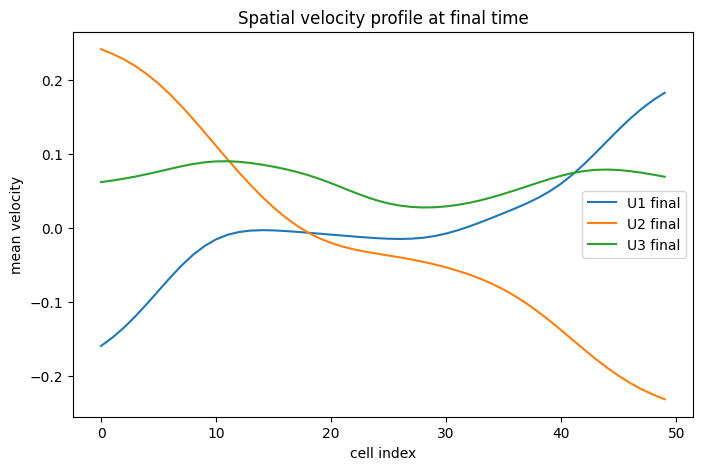

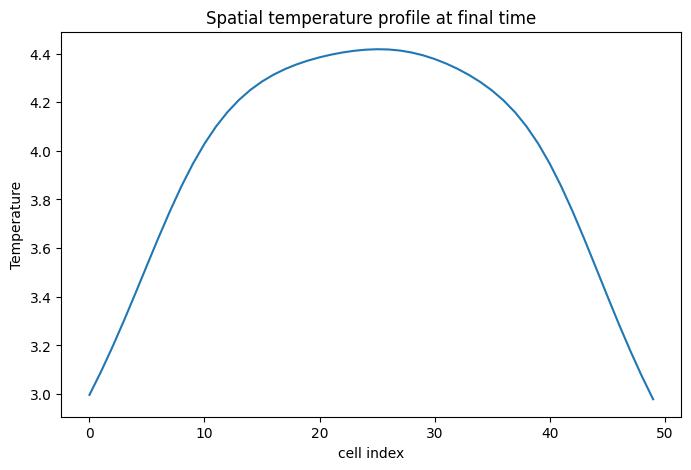

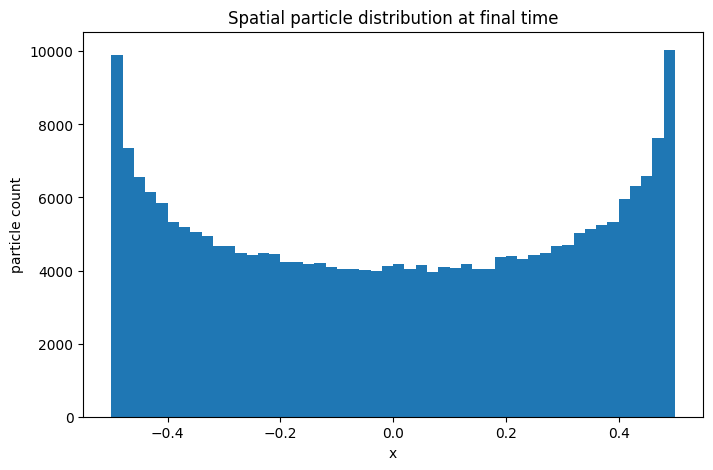

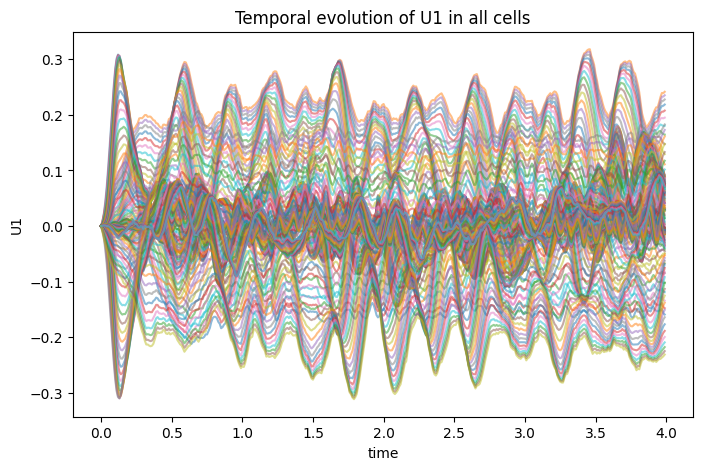

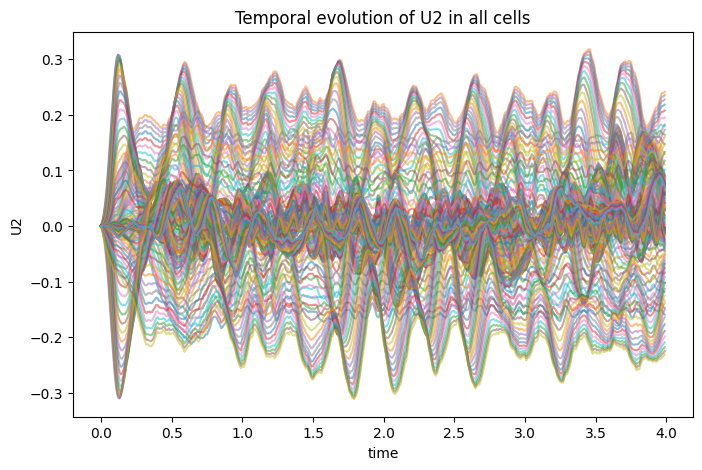

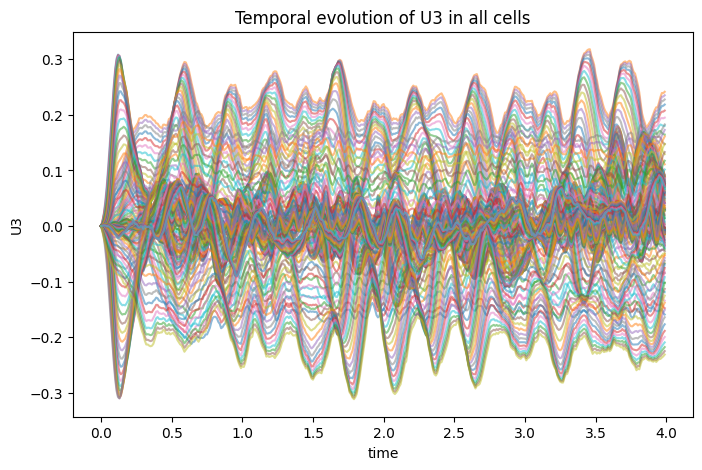

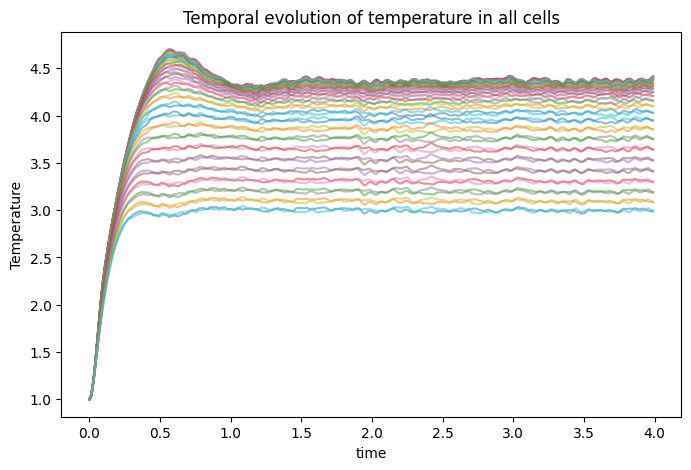

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()
plt.figure(figsize=(8,5))
plt.hist(X, bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()
plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()

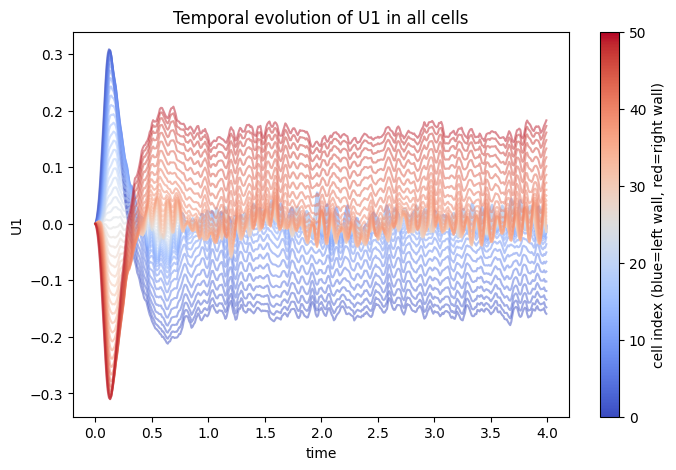

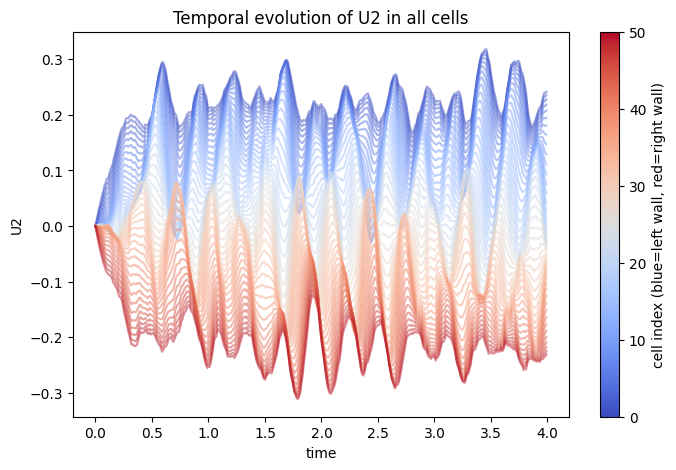

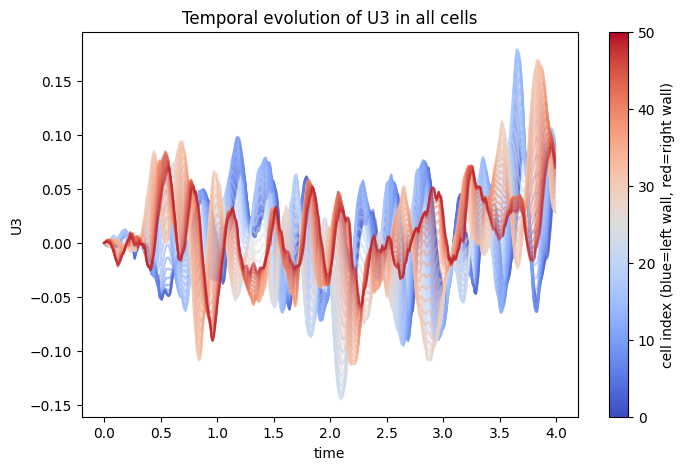

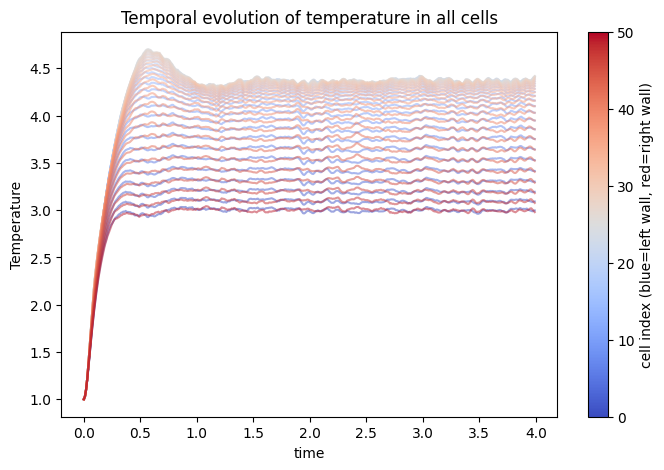

In [9]:
# Temporal U1
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,0], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U1')
ax.set_title('Temporal evolution of U1 in all cells')
plt.show()

# Temporal U2
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,1], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U2')
ax.set_title('Temporal evolution of U2 in all cells')
plt.show()

# Temporal U3
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, U[:,c,2], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('U3')
ax.set_title('Temporal evolution of U3 in all cells')
plt.show()

# Temporal temperature
fig, ax = plt.subplots(figsize=(8,5))
for c in range(Nc):
    ax.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5,
            color=plt.cm.coolwarm(c/Nc))
sm = ScalarMappable(cmap='coolwarm', norm=Normalize(vmin=0, vmax=Nc))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='cell index (blue=left wall, red=right wall)')
ax.set_xlabel('time')
ax.set_ylabel('Temperature')
ax.set_title('Temporal evolution of temperature in all cells')
plt.show()

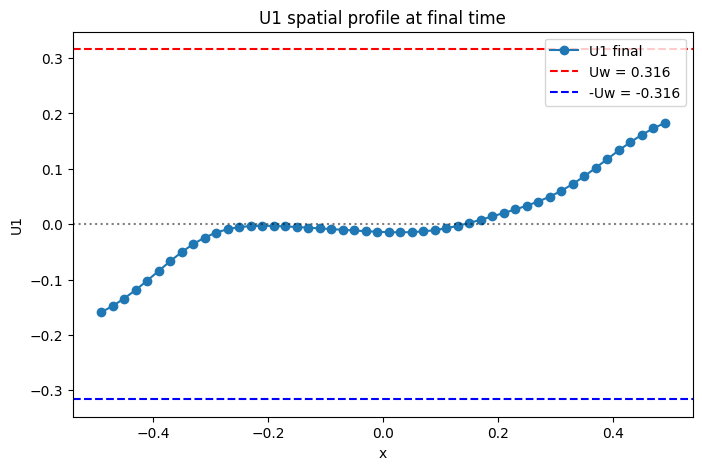

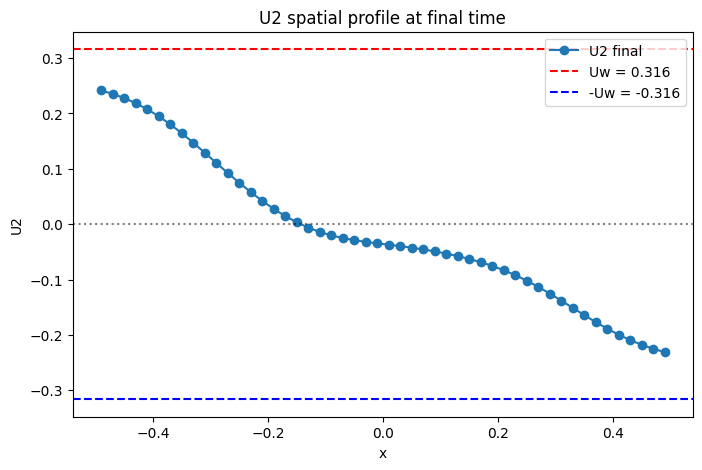

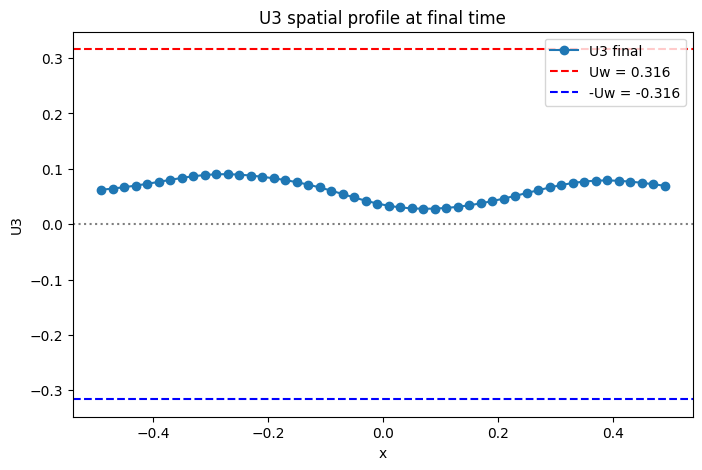

In [10]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 0], 'o-', label='U1 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U1')
plt.title('U1 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 2], 'o-', label='U3 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U3')
plt.title('U3 spatial profile at final time')
plt.legend()
plt.show()

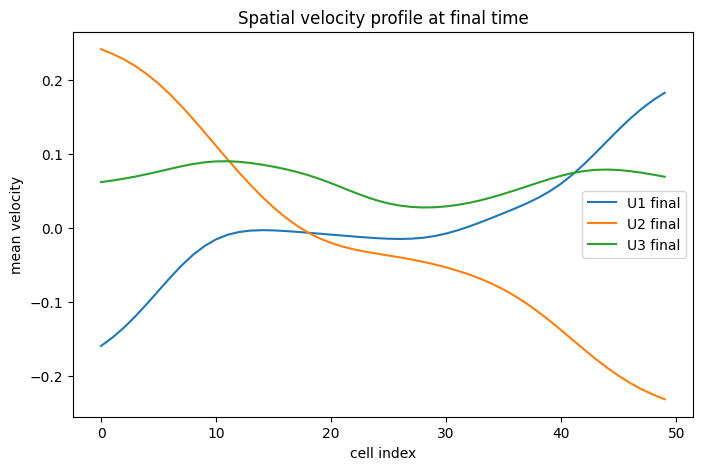

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

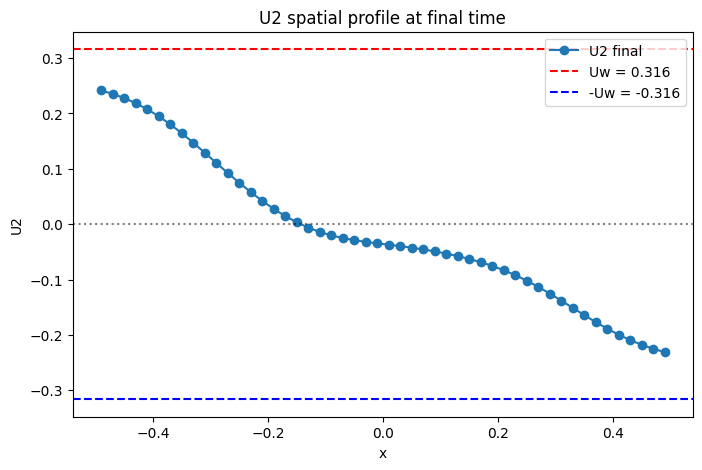

In [12]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()

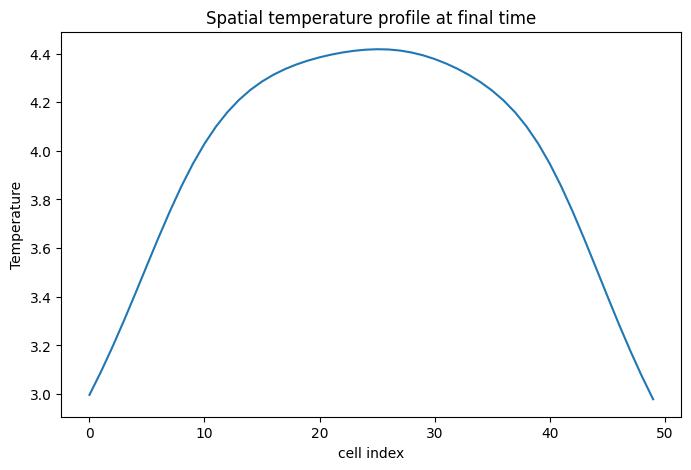

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()

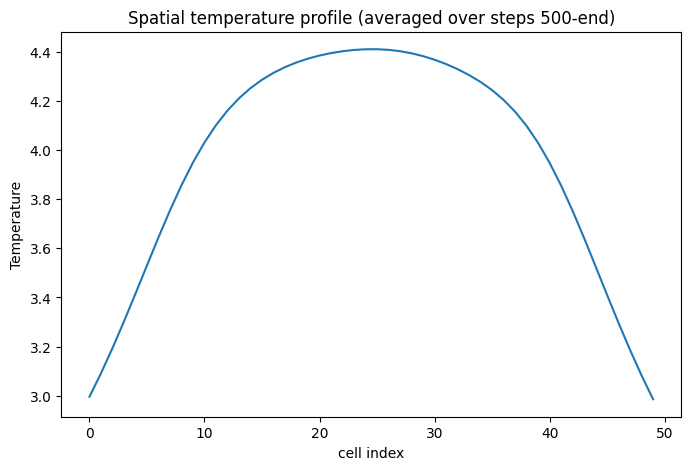

In [14]:
T_avg = np.mean(T[-2:, :], axis=0)  
plt.figure(figsize=(8,5))
plt.plot(range(Nc), T_avg)  
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile (averaged over steps 500-end)')
plt.show()